In [18]:
import tensorflow as tf
import numpy as np
import pickle
import time
import pandas as pd
import matplotlib.pyplot as plt

# Do not change this
def preprocess():
    pickle_obj = pickle.load(open('face_all.pickle', 'rb'))
    features = pickle_obj['Features']
    labels = pickle_obj['Labels']
    train_x = features[0:21100] / 255.0
    valid_x = features[21100:23765] / 255.0
    test_x = features[23765:] / 255.0

    labels = labels.T
    train_y = np.zeros(shape=(21100, 2))
    train_l = labels[0:21100]
    valid_y = np.zeros(shape=(2665, 2))
    valid_l = labels[21100:23765]
    test_y = np.zeros(shape=(2642, 2))
    test_l = labels[23765:]
    for i in range(train_y.shape[0]):
        train_y[i, train_l[i]] = 1
    for i in range(valid_y.shape[0]):
        valid_y[i, valid_l[i]] = 1
    for i in range(test_y.shape[0]):
        test_y[i, test_l[i]] = 1

    return train_x, train_y, valid_x, valid_y, test_x, test_y

# Parameters
learning_rate = 0.0001
training_epochs = 100
batch_size = 100

# Load data before defining the model
train_x, train_y, valid_x, valid_y, test_x, test_y = preprocess()

# Define the model with a variable number of hidden layers
def create_multilayer_perceptron(num_hidden_layers):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(256, activation='relu', input_shape=(train_x.shape[1],)))

    # Add the specified number of hidden layers
    for _ in range(num_hidden_layers - 1):
        model.add(tf.keras.layers.Dense(256, activation='relu'))

    model.add(tf.keras.layers.Dense(2))  # logits for 2 classes
    return model

# List of hidden layer configurations to test
hidden_layer_counts = [2, 3, 4, 5, 6, 7]

results_df = pd.DataFrame(columns=['no. of Hidden Layers', 'Training Time', 'Test Accuracy'])

for num_hidden_layers in hidden_layer_counts:
    print(f"\nTraining model with {num_hidden_layers} hidden layers:")

    # Instantiate and compile the model
    model = create_multilayer_perceptron(num_hidden_layers)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    start = time.time()
    # Train the model
    model.fit(train_x, train_y, epochs=training_epochs, batch_size=batch_size, validation_data=(valid_x, valid_y), verbose=0)
    end = time.time()
    print(f"Training time for {num_hidden_layers} hidden layers: {end - start:.2f} seconds")

    # Evaluate the model on the test data
    test_loss, test_accuracy = model.evaluate(test_x, test_y, verbose=0)
    print(f"Test Accuracy for {num_hidden_layers} hidden layers: {100*test_accuracy:.4f}")
    new_row = {'no. of Hidden Layers': num_hidden_layers, 'Training Time': end - start, 'Test Accuracy': 100*test_accuracy}
    results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)






Training model with 2 hidden layers:


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training time for 2 hidden layers: 408.08 seconds
Test Accuracy for 2 hidden layers: 87.9637

Training model with 3 hidden layers:


<ipython-input-18-f0cf4c79c527>:79: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)


Training time for 3 hidden layers: 434.44 seconds
Test Accuracy for 3 hidden layers: 88.0772

Training model with 4 hidden layers:
Training time for 4 hidden layers: 430.90 seconds
Test Accuracy for 4 hidden layers: 88.2665

Training model with 5 hidden layers:
Training time for 5 hidden layers: 448.88 seconds
Test Accuracy for 5 hidden layers: 88.2286

Training model with 6 hidden layers:
Training time for 6 hidden layers: 467.49 seconds
Test Accuracy for 6 hidden layers: 87.0553

Training model with 7 hidden layers:
Training time for 7 hidden layers: 524.72 seconds
Test Accuracy for 7 hidden layers: 87.2067


In [19]:
results_df

,no. of Hidden Layers,Training Time,Test Accuracy
0,2,408.075324,87.963665
1,3,434.441985,88.077211
2,4,430.896043,88.266462
3,5,448.875243,88.228613
4,6,467.493162,87.055260
5,7,524.717595,87.206662


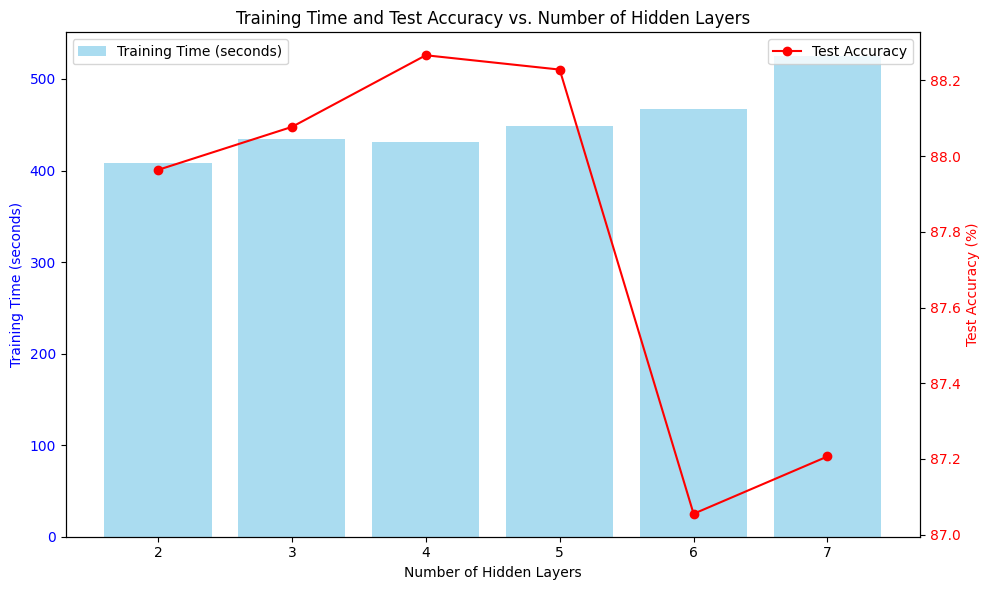

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data
data = {
    'No. of Hidden Layers': [2, 3, 4, 5, 6, 7],
    'Training Time': [408.075324, 434.441985, 430.896043, 448.875243, 467.493162, 524.717595],
    'Test Accuracy': [87.963665, 88.077211, 88.266462, 88.228613, 87.055260, 87.206662]
}
df = pd.DataFrame(data)

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Training Time
ax1.bar(df['No. of Hidden Layers'], df['Training Time'], color='skyblue', label='Training Time (seconds)', alpha=0.7)
ax1.set_xlabel('Number of Hidden Layers')
ax1.set_ylabel('Training Time (seconds)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Line plot for Test Accuracy on a secondary y-axis
ax2 = ax1.twinx()
ax2.plot(df['No. of Hidden Layers'], df['Test Accuracy'], color='red', marker='o', label='Test Accuracy')
ax2.set_ylabel('Test Accuracy (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Titles and Legends
ax1.set_title('Training Time and Test Accuracy vs. Number of Hidden Layers')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Show the plot
plt.tight_layout()
plt.show()


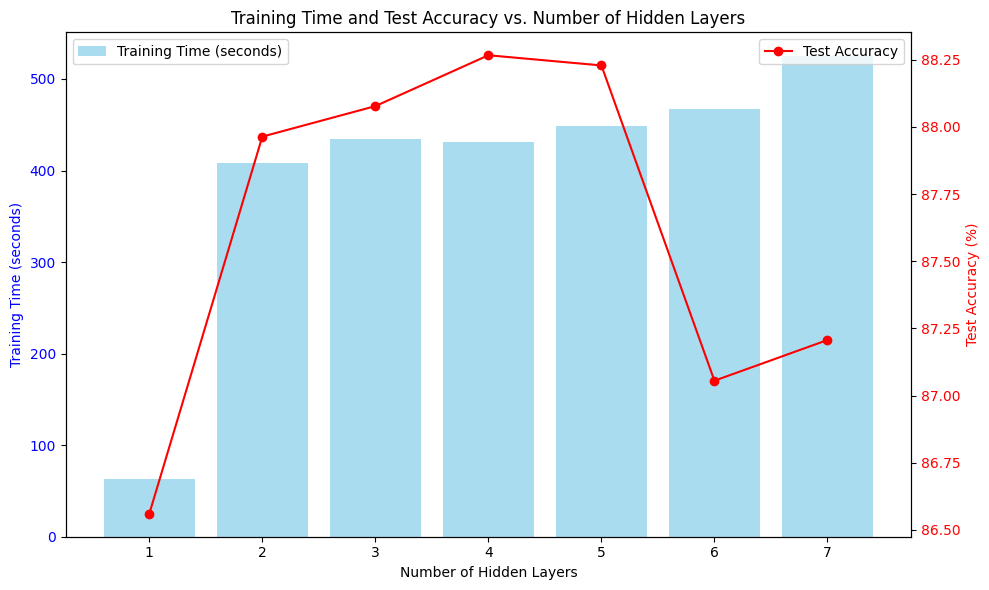

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data
data = {
    'No. of Hidden Layers': [1, 2, 3, 4, 5, 6, 7],
    'Training Time': [62.555, 408.075324, 434.441985, 430.896043, 448.875243, 467.493162, 524.717595],
    'Test Accuracy': [86.56, 87.963665, 88.077211, 88.266462, 88.228613, 87.055260, 87.206662]
}
df = pd.DataFrame(data)

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Training Time
ax1.bar(df['No. of Hidden Layers'], df['Training Time'], color='skyblue', label='Training Time (seconds)', alpha=0.7)
ax1.set_xlabel('Number of Hidden Layers')
ax1.set_ylabel('Training Time (seconds)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Line plot for Test Accuracy on a secondary y-axis
ax2 = ax1.twinx()
ax2.plot(df['No. of Hidden Layers'], df['Test Accuracy'], color='red', marker='o', label='Test Accuracy')
ax2.set_ylabel('Test Accuracy (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Titles and Legends
ax1.set_title('Training Time and Test Accuracy vs. Number of Hidden Layers')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Show the plot
plt.tight_layout()
plt.show()
